# 02 — Ground Data: Temporal Splits and Baseline Models

## Purpose
This notebook defines site-specific time-based splits (train, validation, test) using the aligned ground datasets
exported in Notebook 01. It then establishes simple baseline forecasts to quantify task difficulty before any
machine learning models are introduced.

**Inputs**
- data/ground_aligned/ground_10min_utc_uniandes.parquet
- data/ground_aligned/ground_10min_utc_elpaso.parquet


## Imports and settings

In [1]:
from __future__ import annotations

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data" / "ground_aligned"

UNI_PATH = DATA_DIR / "ground_10min_utc_uniandes.parquet"
ELP_PATH = DATA_DIR / "ground_10min_utc_elpaso.parquet"

print("UNI exists:", UNI_PATH.exists(), "->", UNI_PATH)
print("ELP exists:", ELP_PATH.exists(), "->", ELP_PATH)


UNI exists: True -> /srv/projects/Proyecto_e_ladino/data/ground_aligned/ground_10min_utc_uniandes.parquet
ELP exists: True -> /srv/projects/Proyecto_e_ladino/data/ground_aligned/ground_10min_utc_elpaso.parquet


## Loading datasets

In [2]:
uni = pd.read_parquet(UNI_PATH)
elp = pd.read_parquet(ELP_PATH)

# Expected: UTC time index and a 'ghi' column
print("UNI shape:", uni.shape, "| tz:", uni.index.tz)
print("ELP shape:", elp.shape, "| tz:", elp.index.tz)

display(uni.head(3))
display(elp.head(3))

assert "ghi" in uni.columns, "UNI missing 'ghi' column"
assert "ghi" in elp.columns, "ELP missing 'ghi' column"
assert str(uni.index.tz) == "UTC", "UNI index is not UTC"
assert str(elp.index.tz) == "UTC", "ELP index is not UTC"


UNI shape: (82657, 6) | tz: UTC
ELP shape: (107172, 9) | tz: UTC


,relative_humidity_pct,air_pressure_hpa,wind_direction_deg,ghi,air_temperature_c,wind_speed_ms
2023-09-01 05:00:00+00:00,73.896,745.288,163.000,0.0,12.718,1.042
2023-09-01 05:10:00+00:00,76.484,745.140,113.694,0.0,11.932,2.728
2023-09-01 05:20:00+00:00,75.824,744.972,116.006,0.0,12.318,1.346


,clear_sky_index,ghi,air_pressure_hpa,air_temperature_c,wind_y,wind_x,doy_sin,doy_cos,hour_of_day
2022-02-21 18:00:00+00:00,2.0,3.0352,1000.7912,29.9672,2.832954,-0.093612,0.778764,0.627317,18
2022-02-21 18:10:00+00:00,0.0,0.3562,1000.9321,29.5689,3.387552,0.796801,0.778764,0.627317,18
2022-02-21 18:20:00+00:00,0.0,0.0000,1001.1479,29.2593,2.091197,-0.878680,0.778764,0.627317,18


## Horizon configuration

In [3]:
FREQ_MIN = 10
HOURS_AHEAD = 6
H = int((HOURS_AHEAD * 60) / FREQ_MIN)

print("Forecast horizon:", HOURS_AHEAD, "hours")
print("Horizon steps:", H, f"({H} steps × {FREQ_MIN} min = {H*FREQ_MIN} min)")

Forecast horizon: 6 hours
Horizon steps: 36 (36 steps × 10 min = 360 min)


## Split definition

- Splits are time-blocked to prevent leakage.
- Each site uses its own calendar boundaries due to different coverage.

In [4]:
SPLITS = {
    "uniandes": {
        "train": ("2023-09-01", "2024-09-30"),
        "val":   ("2024-10-01", "2024-12-31"),
        "test":  ("2025-01-01", "2025-03-28"),
    },
    "elpaso": {
        "train": ("2022-03-01", "2023-06-30"),
        "val":   ("2023-07-01", "2023-10-31"),
        "test":  ("2023-11-01", "2024-03-07"),
    },
}

In [5]:
def slice_by_date(df: pd.DataFrame, start: str, end: str) -> pd.DataFrame:
    start_ts = pd.Timestamp(start, tz="UTC")
    end_ts = pd.Timestamp(end, tz="UTC")
    return df.loc[(df.index >= start_ts) & (df.index < end_ts)].copy()

def build_splits(df: pd.DataFrame, site_key: str) -> dict[str, pd.DataFrame]:
    spec = SPLITS[site_key]
    out = {}
    for name, (s, e) in spec.items():
        out[name] = slice_by_date(df, s, e)
    return out

uni_splits = build_splits(uni, "uniandes")
elp_splits = build_splits(elp, "elpaso")

for k, v in uni_splits.items():
    print("UNI", k, v.index.min(), "→", v.index.max(), "| rows:", len(v))
for k, v in elp_splits.items():
    print("ELP", k, v.index.min(), "→", v.index.max(), "| rows:", len(v))

UNI train 2023-09-01 05:00:00+00:00 → 2024-09-29 23:50:00+00:00 | rows: 56850
UNI val 2024-10-01 00:00:00+00:00 → 2024-12-30 23:50:00+00:00 | rows: 13104
UNI test 2025-01-01 00:00:00+00:00 → 2025-03-27 23:50:00+00:00 | rows: 12384
ELP train 2022-03-01 00:00:00+00:00 → 2023-06-29 23:50:00+00:00 | rows: 69984
ELP val 2023-07-01 00:00:00+00:00 → 2023-10-30 23:50:00+00:00 | rows: 17568
ELP test 2023-11-01 00:00:00+00:00 → 2024-03-06 23:50:00+00:00 | rows: 18288


### Sanity check

In [6]:
rows = []

for site, splits in [("uniandes", uni_splits), ("elpaso", elp_splits)]:
    total_rows = sum(len(df) for df in splits.values())

    for split_name, df in splits.items():
        n_split = len(df)
        pct_of_total = 100.0 * n_split / total_rows if total_rows > 0 else 0.0

        rows.append({
            "site": site,
            "split": split_name,
            "rows_in_split": n_split,
            "pct_of_site_total": round(pct_of_total, 2),
        })

split_share_df = (
    pd.DataFrame(rows)
    .sort_values(["site", "split"])
)

display(split_share_df)

,site,split,rows_in_split,pct_of_site_total
5,elpaso,test,18288,17.28
3,elpaso,train,69984,66.12
4,elpaso,val,17568,16.60
2,uniandes,test,12384,15.04
0,uniandes,train,56850,69.04
1,uniandes,val,13104,15.91


## Baselines

### Definition

In [7]:
def rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def mae(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.mean(np.abs(y_true - y_pred)))

def build_supervised(df: pd.DataFrame, y_col: str, horizon_steps: int) -> pd.DataFrame:
    out = df[[y_col]].copy()
    out["y"] = out[y_col].shift(-horizon_steps)
    out["x_persist"] = out[y_col]
    out = out.dropna(subset=["y", "x_persist"])
    return out

def eval_persistence(df: pd.DataFrame, horizon_steps: int, y_col: str = "ghi") -> dict:
    sup = build_supervised(df, y_col=y_col, horizon_steps=horizon_steps)
    y = sup["y"].to_numpy()
    yhat = sup["x_persist"].to_numpy()
    return {
        "n": int(len(sup)),
        "rmse": rmse(y, yhat),
        "mae": mae(y, yhat),
    }

### Run and summarize   

In [9]:
def run_site_baselines(site_name: str, splits: dict[str, pd.DataFrame], horizon_steps: int) -> pd.DataFrame:
    train = splits["train"]
    # hourly_mean = fit_hourly_climatology(train, y_col="ghi")

    rows = []
    for split_name, df in splits.items():
        p = eval_persistence(df, horizon_steps=horizon_steps, y_col="ghi")
        # c = eval_hourly_climatology(df, hourly_mean, horizon_steps=horizon_steps, y_col="ghi")
        rows.append({
            "site": site_name,
            "split": split_name,
            "n": p["n"],
            "persistence_rmse": p["rmse"],
            "persistence_mae": p["mae"],
            # "hourly_clim_rmse": c["rmse"],
            # "hourly_clim_mae": c["mae"],
        })

    return pd.DataFrame(rows)

uni_res = run_site_baselines("uniandes", uni_splits, H)
elp_res = run_site_baselines("elpaso", elp_splits, H)

results = pd.concat([uni_res, elp_res], ignore_index=True)
display(results.sort_values(["site", "split"]))

,site,split,n,persistence_rmse,persistence_mae
5,elpaso,test,18252,496.890166,368.027576
3,elpaso,train,69948,479.639079,337.048988
4,elpaso,val,17532,508.029596,371.921232
2,uniandes,test,12348,389.566436,251.481440
0,uniandes,train,56693,421.675177,283.343620
1,uniandes,val,13066,380.738191,250.960393


### Sanity check

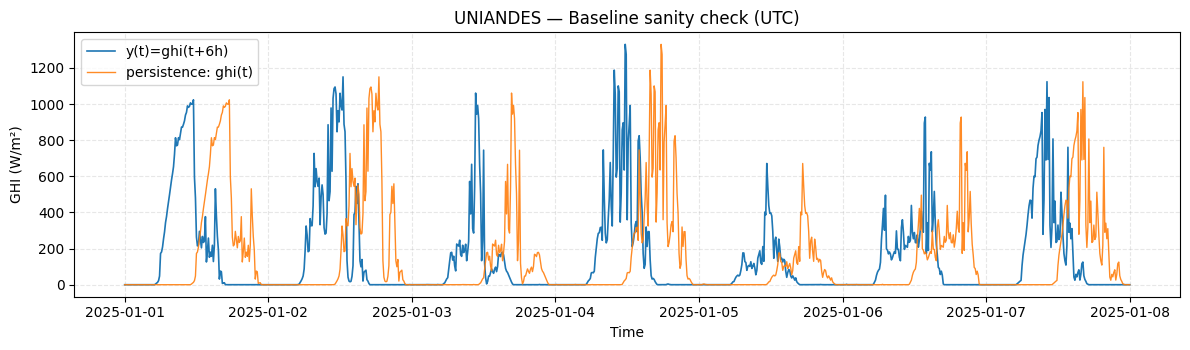

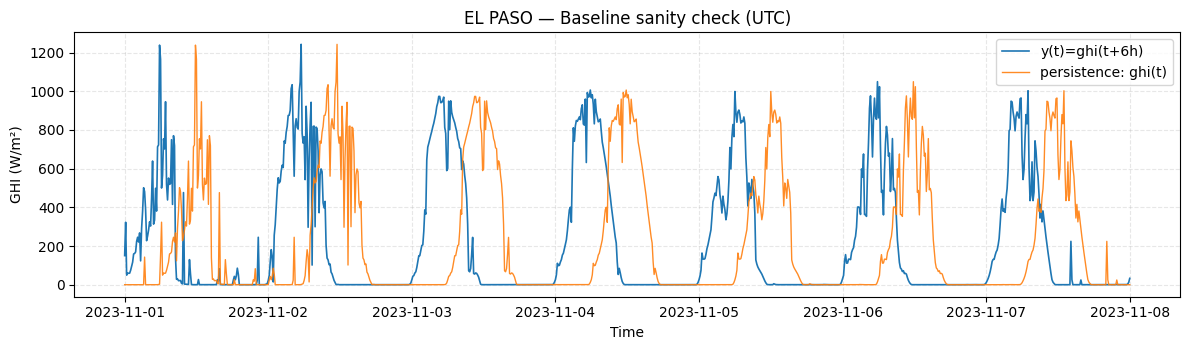

In [10]:
def plot_baseline_window(df: pd.DataFrame, horizon_steps: int, title: str, days: int = 7):
    sup = build_supervised(df, y_col="ghi", horizon_steps=horizon_steps)
    if sup.empty:
        print("No supervised rows available for plotting.")
        return

    start = sup.index.min()
    end = start + pd.Timedelta(days=days)
    w = sup.loc[(sup.index >= start) & (sup.index <= end)].copy()

    plt.figure(figsize=(12, 3.6))
    plt.plot(w.index, w["y"], label=f"y(t)=ghi(t+{HOURS_AHEAD}h)", linewidth=1.2)
    plt.plot(w.index, w["x_persist"], label="persistence: ghi(t)", linewidth=1.0, alpha=0.9)
    plt.title(title + " (UTC)")
    plt.xlabel("Time")
    plt.ylabel("GHI (W/m²)")
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_baseline_window(uni_splits["test"], H, "UNIANDES — Baseline sanity check", days=7)
plot_baseline_window(elp_splits["test"], H, "EL PASO — Baseline sanity check", days=7)

## Export

In [12]:
OUT_DIR = PROJECT_ROOT / "runs" / "ground_baselines"
OUT_DIR.mkdir(parents=True, exist_ok=True)

out_path = OUT_DIR / f"baselines_H{HOURS_AHEAD}h.parquet"
results.to_parquet(out_path, index=False)

print("Saved:", out_path)

Saved: /srv/projects/Proyecto_e_ladino/runs/ground_baselines/baselines_H6h.parquet
